In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [118]:
# 300 steps
sc_acc = pd.read_csv("../TrainingPlotsViz/sc.csv")
sc_sce = pd.read_csv("../TrainingPlotsViz/sc_sce.csv")

prm_acc = pd.read_csv("../TrainingPlotsViz/prm_acc.csv")
prm_adv = pd.read_csv("../TrainingPlotsViz/prm_adv.csv")

prm_int_acc = pd.read_csv("../TrainingPlotsViz/prm_acc_w_int.csv")
prm_int_adv = pd.read_csv("../TrainingPlotsViz/prm_adv_w_int.csv")

token_acc = pd.read_csv("../TrainingPlotsViz/token_entropy.csv")
traj_acc = pd.read_csv("../TrainingPlotsViz/traj_entropy.csv")

token_adv = pd.read_csv("../TrainingPlotsViz/token_adv.csv")
traj_adv = pd.read_csv("../TrainingPlotsViz/traj_adv.csv")

In [119]:
sc_acc['rolling_corr_int'] = sc_acc['mean_rewards'].rolling(15).corr(sc_sce['mean_advantage'])
prm_acc['rolling_corr_prm'] = prm_acc['mean_rewards'].rolling(15).corr(prm_adv['mean_advantage'])
prm_int_acc['rolling_corr_comb'] = prm_int_acc['mean_rewards'].rolling(15).corr(prm_int_adv['mean_advantage'])

token_acc['rolling_corr_token'] = token_acc['mean_ac_reward'].rolling(15).corr(token_adv['mean_advantage'])
traj_acc['rolling_corr_traj'] = traj_acc['mean_ac_reward'].rolling(15).corr(traj_adv['mean_advantage'])

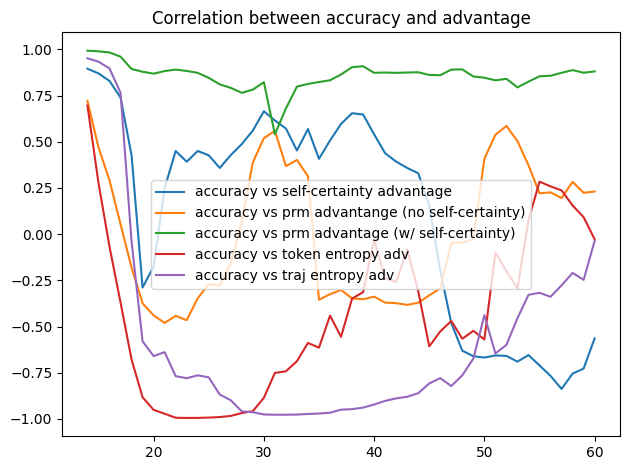

In [120]:
plt.plot(sc_acc['rolling_corr_int'], label='accuracy vs self-certainty advantage')
plt.plot(prm_acc['rolling_corr_prm'], label='accuracy vs prm advantange (no self-certainty)')
plt.plot(prm_int_acc['rolling_corr_comb'], label='accuracy vs prm advantage (w/ self-certainty)')

plt.plot(token_acc['rolling_corr_token'], label='accuracy vs token entropy adv')
plt.plot(traj_acc['rolling_corr_traj'], label='accuracy vs traj entropy adv')

plt.legend()
plt.title('Correlation between accuracy and advantage')
plt.tight_layout()
plt.show()

In [96]:
sc_acc

,train/global_step,Qwen2.5-3B-INT-300steps - _step,Qwen2.5-3B-INT-300steps - _step__MIN,Qwen2.5-3B-INT-300steps - _step__MAX,mean_rewards,Qwen2.5-3B-INT-300steps - train/rewards/accuracy_reward/mean__MIN,Qwen2.5-3B-INT-300steps - train/rewards/accuracy_reward/mean__MAX,rolling_corr,rolling_corr_int
0,1,117,117,117,0.384813,0.384813,0.384813,NaN,NaN
1,5,587,587,587,0.333012,0.333012,0.333012,NaN,NaN
2,10,1174,1174,1174,0.343756,0.343756,0.343756,NaN,NaN
3,15,1761,1761,1761,0.447104,0.447104,0.447104,NaN,NaN
4,20,2348,2348,2348,0.525869,0.525869,0.525869,NaN,NaN
...,...,...,...,...,...,...,...,...,...
56,280,8216,8216,8216,0.018053,0.018053,0.018053,-0.481883,-0.481883
57,285,8803,8803,8803,0.017503,0.017503,0.017503,-0.509892,-0.509892
58,290,9390,9390,9390,0.018790,0.018790,0.018790,-0.517423,-0.517423
59,295,9977,9977,9977,0.015701,0.015701,0.015701,-0.526959,-0.526959


In [121]:
save_df = prm_acc[['train/global_step', 'rolling_corr_prm']]

In [122]:
save_df['rolling_corr_int'] = sc_acc['rolling_corr_int']
save_df['rolling_corr_comb'] = prm_int_acc['rolling_corr_comb']
save_df['rolling_corr_token'] = token_acc['rolling_corr_token']
save_df['rolling_corr_traj'] = traj_acc['rolling_corr_traj']

/var/folders/kh/5yxw6drd3zg5gk2n8k9_1jd00000gq/T/ipykernel_20664/2304333030.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  save_df['rolling_corr_int'] = sc_acc['rolling_corr_int']
/var/folders/kh/5yxw6drd3zg5gk2n8k9_1jd00000gq/T/ipykernel_20664/2304333030.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  save_df['rolling_corr_comb'] = prm_int_acc['rolling_corr_comb']
/var/folders/kh/5yxw6drd3zg5gk2n8k9_1jd00000gq/T/ipykernel_20664/2304333030.py:3: SettingWithCopyWarning: 
A value is trying to be set 

In [123]:
save_df.to_csv('correlations_all.csv')

In [113]:
save_df[:15]

,train/global_step,rolling_corr_prm,rolling_corr_int,rolling_corr_comb
0,1,NaN,NaN,NaN
1,5,NaN,NaN,NaN
2,10,NaN,NaN,NaN
3,15,NaN,NaN,NaN
4,20,NaN,NaN,NaN
5,25,NaN,NaN,NaN
6,30,NaN,NaN,NaN
7,35,NaN,NaN,NaN
8,40,NaN,NaN,NaN
9,45,NaN,NaN,NaN


In [135]:
sc_acc['mean_rewards'].corr(sc_sce['mean_advantage']), prm_acc['mean_rewards'].corr(prm_adv['mean_advantage']), prm_int_acc['mean_rewards'].corr(prm_int_adv['mean_advantage']), token_acc['mean_ac_reward'].corr(token_adv['mean_advantage']),traj_acc['mean_ac_reward'].corr(traj_adv['mean_advantage'])

(np.float64(0.15029959331261583),
 np.float64(-0.5419371464899132),
 np.float64(0.9723372255852415),
 np.float64(-0.5751060644146039),
 np.float64(-0.2610330283806661))

In [ ]:
sc_acc['rolling_corr_int'] = sc_acc['mean_rewards'].rolling(15).corr(sc_sce['mean_advantage'])
prm_acc['rolling_corr_prm'] = prm_acc['mean_rewards'].rolling(15).corr(prm_adv['mean_advantage'])
prm_int_acc['rolling_corr_comb'] = prm_int_acc['mean_rewards'].rolling(15).corr(prm_int_adv['mean_advantage'])

token_acc['rolling_corr_token'] = token_acc['mean_ac_reward'].rolling(15).corr(token_adv['mean_advantage'])
traj_acc['rolling_corr_traj'] = traj_acc['mean_ac_reward'].rolling(15).corr(traj_adv['mean_advantage'])